In [ ]:
# HIPÓTESIS 1
# Los alojamientos ubicados en el Centro tienen precios más altos que los alojamientos del resto de barrios.

# JUSTIFICACIÓN DE LA HIPÓTESIS
# El Centro concentra la mayor parte de la oferta (6389 alojamientos), es la zona más turística y suele tener mayor demanda, 
# lo que razonablemente podría elevar los precios.

# PLAN DE ACCIÓN
# Si la hipótesis se confirma:
# - Analizaremos qué factores dentro del Centro explican ese precio más alto:
#       - tipo de habitación (room_type)
#       - número de reseñas (number_of_reviews)
#       - disponibilidad anual (availability_365)
#       - actividad mensual (reviews_per_month)

# Compararemos el Centro con los dos siguientes barrios más relevantes para ver si la diferencia es estructural o puntual.

# Si la hipótesis no se confirma:
# - Analizaremos cuales son los factores que más influyen en el precio medio:
#       - Tipo de habitación (room_type)
#       - Número de reseñas (number_of_reviews)
#       - Disponibilidad anual (availability_365)  
#       - Mínimo de noches (minimum_nights)
#       - Número de alojamientos gestionados por el host (calculated_host_listings_count)  

In [ ]:
# importamos las librerias necesarias y el df que hemos limpiado previamente para analizar los precios en la temporada anterior (2025).
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("../src/data/df_2025.csv")

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6861 entries, 0 to 6860
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            6861 non-null   str    
 1   host_id                         6861 non-null   int64  
 2   host_name                       6861 non-null   str    
 3   neighbourhood                   6861 non-null   str    
 4   room_type                       6861 non-null   str    
 5   price                           6861 non-null   float64
 6   minimum_nights                  6861 non-null   int64  
 7   number_of_reviews               6861 non-null   int64  
 8   last_review                     6861 non-null   str    
 9   reviews_per_month               6861 non-null   float64
 10  calculated_host_listings_count  6861 non-null   int64  
 11  availability_365                6861 non-null   int64  
 12  number_of_reviews_ltm           6861 non-null

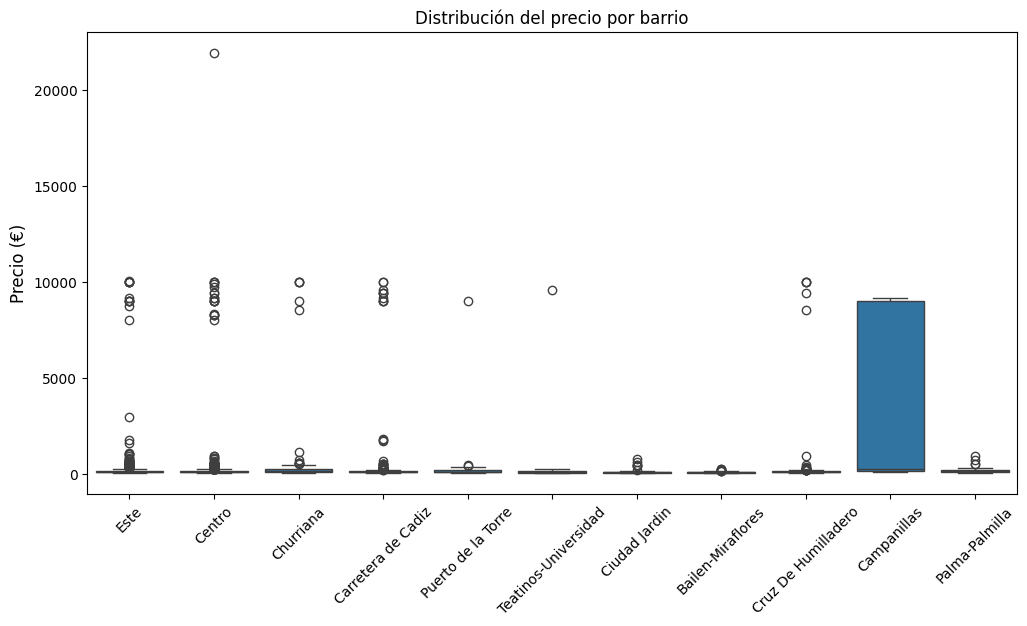

In [ ]:
# Boxplot de la distribución del precio por barrio

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="neighbourhood", y="price")
plt.xticks(rotation=45)
plt.title("Distribución del precio por barrio")
plt.xlabel("")
plt.ylabel("Precio (€)", fontsize = 12)
plt.show()

In [3]:
df.groupby("neighbourhood")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
neighbourhood,,,,,,,,
Bailen-Miraflores,217.0,73.589862,34.870030,18.0,52.0,72.0,89.00,249.0
Campanillas,19.0,2989.210526,4213.307682,56.0,157.5,259.0,9000.00,9143.0
Carretera de Cadiz,666.0,251.097598,1138.625287,23.0,70.0,93.0,124.75,9999.0
Centro,4615.0,157.234670,650.193770,20.0,78.0,101.0,138.00,21911.0
Churriana,110.0,594.290909,1963.638447,27.0,75.0,111.5,231.75,9999.0
Ciudad Jardin,52.0,113.134615,151.273292,22.0,48.0,63.0,83.50,735.0
Cruz De Humilladero,294.0,255.663265,1233.656016,19.0,60.0,84.0,108.00,10000.0
Este,689.0,310.222061,1218.329532,22.0,79.0,101.0,150.00,10014.0
Palma-Palmilla,123.0,141.650407,116.655650,25.0,80.5,127.0,169.00,926.0


In [5]:
# Descartamos la media como medida representativa, ya que la desviación típica es elevada en todos los barrios, lo que indica una fuerte 
# dispersión y presencia de valores extremos. Por ello, utilizamos la mediana como estadístico central más robusto y ordenamos los barrios
# de forma descendente según su mediana de precios.

mediana_precios = df.groupby("neighbourhood")["price"].median().sort_values(ascending=False)
print(mediana_precios)

neighbourhood
Campanillas             259.0
Palma-Palmilla          127.0
Churriana               111.5
Este                    101.0
Centro                  101.0
Puerto de la Torre       99.0
Carretera de Cadiz       93.0
Cruz De Humilladero      84.0
Bailen-Miraflores        72.0
Ciudad Jardin            63.0
Teatinos-Universidad     63.0
Name: price, dtype: float64


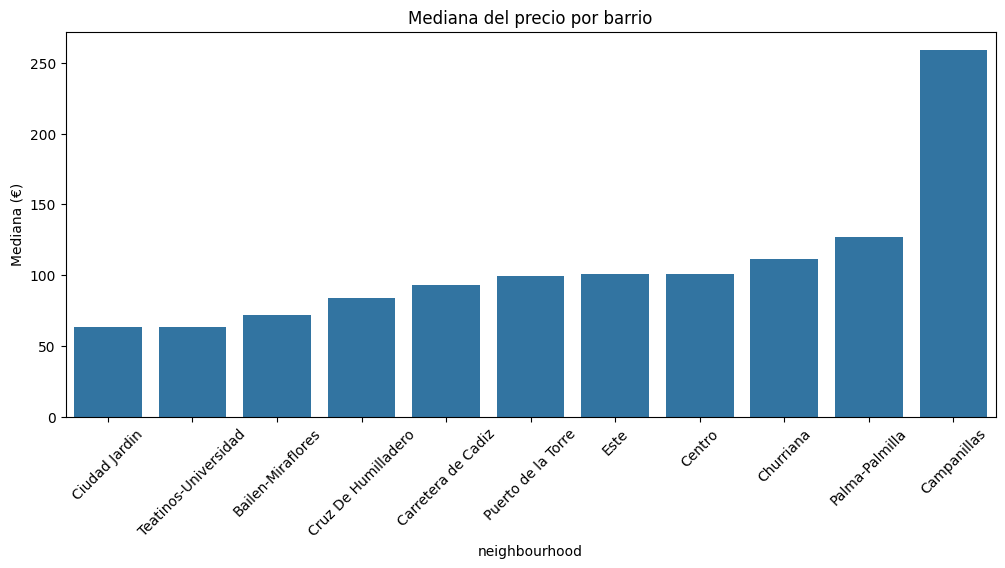

In [7]:
# Representamos la mediana del precio por barrio mediante un gráfico de barras

medianas = df.groupby("neighbourhood")["price"].median().sort_values()

plt.figure(figsize=(12,5))
sns.barplot(x=medianas.index, y=medianas.values)
plt.xticks(rotation=45)
plt.title("Mediana del precio por barrio")
plt.ylabel("Mediana (€)")
plt.show()


Se utiliza la mediana del precio por barrio como medida principal de tendencia central, ya que es menos sensible a valores extremos y ofrece una visión más fiel del comportamiento típico sin requerir la eliminación de outliers.

Al comparar la media y la mediana por barrio, observamos que la media presenta valores anormalmente altos en algunas zonas. Esto se debe a la presencia de alojamientos con precios muy elevados (muy por encima del mercado) que inflan el valor de la media. Estos valores extremos suelen corresponder a viviendas de lujo o propiedades ubicadas en zonas residenciales exclusivas.

La mediana, en cambio, permite describir el precio típico de cada barrio sin que estos casos excepcionales distorsionen el análisis, proporcionando una representación más robusta y realista del comportamiento general del mercado.


In [11]:
# Detectar outliers usando el percentil 99

umbral_99 = df["price"].quantile(0.99)
outliers = df[df["price"] > umbral_99]
outliers


,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,accommodates,review_scores_rating,Segmento Disponibilidad,Segmento Reseñas
248,Beach Living in Malaga,7025320,Lucia,Este,Entire home/apt,2932.0,2,11,2025-06-24,0.80,1,186,6,VFT/MA/69459,4,5.00,Alta,Medias
785,2 bedroom lovely home in Málaga,154046886,Novasol,Este,Entire home/apt,9999.0,1,19,2025-09-10,0.26,1,249,4,VUT/MA/17649,5,4.84,Alta,Medias
1693,Vistas a la bahía de Málaga desde una villa única,336578289,Javier,Este,Entire home/apt,1066.0,4,81,2025-09-28,1.29,1,312,17,VFT/MA/39358,15,4.99,Alta,Muchas
1782,Sleeps 24 with fabulous sea and mountain views,25632968,Claire,Este,Entire home/apt,1590.0,3,28,2025-09-15,0.65,8,332,8,A/MA/01290,16,4.96,Alta,Medias
1937,Teatro Romano 2,383001067,Jose,Centro,Entire home/apt,21911.0,1,163,2025-09-13,2.85,2,308,41,ESFCTU0000290200007573890000000000000000VFT/MA...,3,4.90,Alta,Muchas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,El Pajar,686781509,Michael,Campanillas,Entire home/apt,9000.0,1,1,2025-08-04,0.52,8,364,1,ESHFTU00002900100001917200200000000000000CR/MA...,6,5.00,Alta,Pocas
6441,Awesome home in Málaga with WiFi,153912894,Novasol,Centro,Entire home/apt,9999.0,1,1,2025-09-22,1.00,1,213,1,VUT/MA/93022,3,2.00,Alta,Pocas
6531,Apartamentos sealmar 1,587006009,Michael,Carretera de Cadiz,Entire home/apt,9429.0,1,1,2025-09-02,1.00,6,364,1,ESFCTU0000290530011614110000000000000000VUT/MA...,4,5.00,Alta,Pocas
6602,La Mihilla,686781509,Michael,Campanillas,Entire home/apt,9000.0,1,3,2025-09-06,1.70,8,362,3,VFT/MA/62520,2,5.00,Alta,Pocas


In [12]:
outliers["room_type"].value_counts()

room_type
Entire home/apt    69
Name: count, dtype: int64

In [20]:
outliers["accommodates"].mode()

0    4
Name: accommodates, dtype: int64

In [14]:
outliers["accommodates"].describe()

count    69.000000
mean      5.710145
std       3.044288
min       2.000000
25%       4.000000
50%       5.000000
75%       6.000000
max      16.000000
Name: accommodates, dtype: float64

In [15]:
outliers.groupby("neighbourhood")["availability_365"].median()

neighbourhood
Campanillas             364.0
Carretera de Cadiz      348.0
Centro                  359.0
Churriana               272.0
Cruz De Humilladero     364.0
Este                    352.5
Puerto de la Torre      364.0
Teatinos-Universidad    365.0
Name: availability_365, dtype: float64

In [16]:
outliers.groupby("neighbourhood")["Segmento Reseñas"].value_counts()

neighbourhood         Segmento Reseñas
Campanillas           Pocas                5
                      Medias               1
Carretera de Cadiz    Pocas               10
                      Medias               3
Centro                Pocas               14
                      Medias               3
                      Muchas               2
Churriana             Medias               3
                      Pocas                3
Cruz De Humilladero   Pocas                3
                      Medias               2
Este                  Pocas               11
                      Medias               5
                      Muchas               2
Puerto de la Torre    Pocas                1
Teatinos-Universidad  Pocas                1
Name: count, dtype: int64

In [21]:
outliers.groupby("neighbourhood")["Segmento Disponibilidad"].value_counts()

neighbourhood         Segmento Disponibilidad
Campanillas           Alta                        6
Carretera de Cadiz    Alta                       12
                      Baja                        1
Centro                Alta                       19
Churriana             Alta                        4
                      Baja                        2
Cruz De Humilladero   Alta                        4
                      Baja                        1
Este                  Alta                       16
                      Baja                        2
Puerto de la Torre    Alta                        1
Teatinos-Universidad  Alta                        1
Name: count, dtype: int64

In [17]:
outliers.isnull().sum()

name                              0
host_id                           0
host_name                         0
neighbourhood                     0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
number_of_reviews_ltm             0
license                           0
accommodates                      0
review_scores_rating              0
Segmento Disponibilidad           0
Segmento Reseñas                  0
dtype: int64

Al analizar únicamente los outliers del conjunto de datos, observamos que todos ellos corresponden a apartamentos completos (*Entire home/apt*), lo que indica que los precios extremadamente altos están asociados a viviendas completas y no a habitaciones privadas o compartidas. La moda del número de huéspedes admitidos entre estos alojamientos es de 4, por lo que la mayoría de estas propiedades están orientadas a grupos pequeños o familias.

En cuanto al volumen de reseñas, la mayoría de estos alojamientos se encuentran en el segmento de “Pocas reseñas”, seguido de algunos casos con reseñas medias y muy pocos con un volumen elevado. Esto sugiere que, aunque son alojamientos activos, muchos de ellos no acumulan un historial extenso de estancias, posiblemente por tratarse de propiedades de gama alta o con precios elevados que limitan su rotación.

Además, todos los outliers identificados cuentan con licencia y presentan una disponibilidad anual alta, lo que confirma que son alojamientos plenamente operativos y no anuncios residuales. En conjunto, estos resultados indican que los precios extremos del dataset provienen de apartamentos completos, con capacidad típica para 4 personas, regulados y con actividad estable, pero con un volumen de reseñas generalmente bajo.


In [57]:
# Analizamos el precio por persona / barrio, para ello creamos una nueva columna en el dataframe
df["precio_por_persona"] = df["price"] / df["accommodates"]
df.groupby(["neighbourhood"])["precio_por_persona"].median().sort_values(ascending=False)



neighbourhood
Campanillas             50.500000
Palma-Palmilla          33.500000
Centro                  30.000000
Churriana               29.425000
Este                    29.250000
Ciudad Jardin           25.583333
Puerto de la Torre      25.500000
Carretera de Cadiz      25.166667
Cruz De Humilladero     24.633333
Bailen-Miraflores       21.250000
Teatinos-Universidad    20.000000
Name: precio_por_persona, dtype: float64

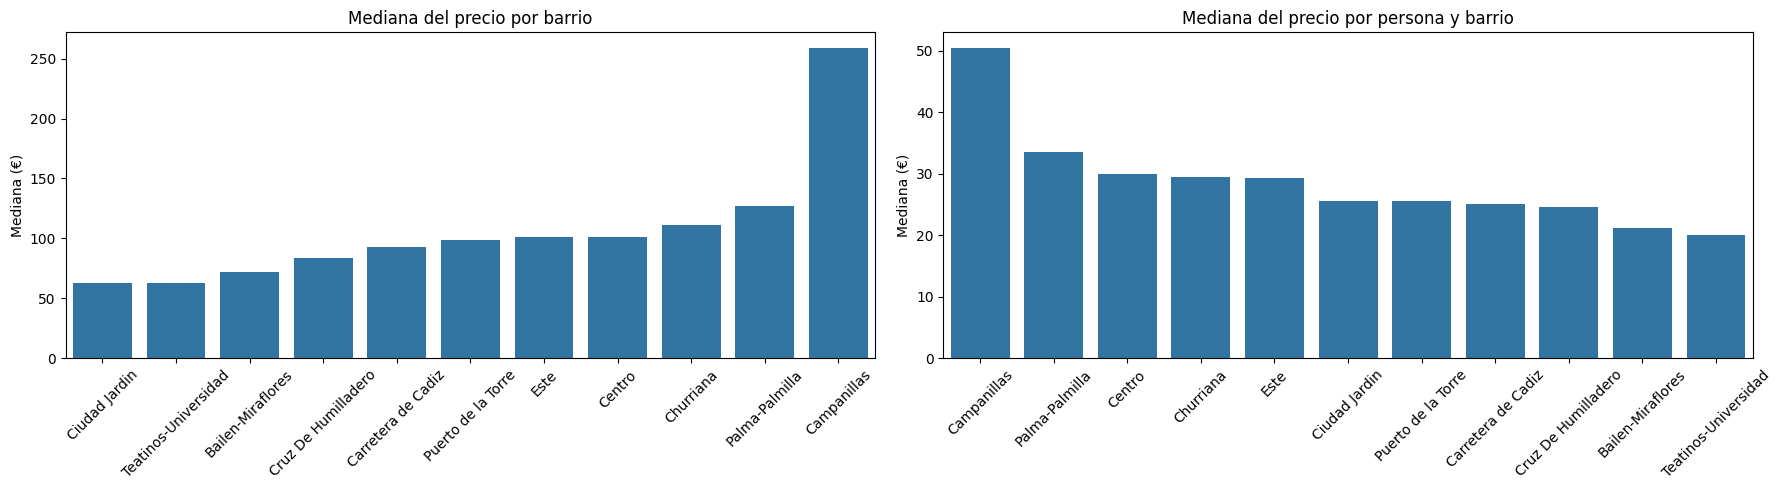

In [63]:
# Comparación de la mediana en precio por barrio y precio por persona y barrio

fig, axes = plt.subplots(1, 2, figsize=(18,5))

# --- Gráfico 1: Mediana del precio por barrio ---
sns.barplot(
    ax=axes[0],
    x=medianas.index,
    y=medianas.values
)
axes[0].set_title("Mediana del precio por barrio")
axes[0].set_ylabel("Mediana (€)")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=45)

# --- Gráfico 2: Mediana del precio por persona y barrio ---
sns.barplot(
    ax=axes[1],
    x=medianas_por_persona.index,
    y=medianas_por_persona.values
)
axes[1].set_title("Mediana del precio por persona y barrio")
axes[1].set_ylabel("Mediana (€)")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


La comparación entre la mediana del precio total y la mediana del precio por persona revela diferencias importantes entre barrios. Campanillas destaca como la zona más cara tanto en términos absolutos como por persona, lo que indica un mercado claramente premium. En contraste, barrios como Centro o Churriana presentan precios totales elevados, pero su precio por persona es más moderado debido a una mayor capacidad de los alojamientos.

Por otro lado, zonas como Palma-Palmilla muestran precios totales relativamente bajos, pero un precio por persona más elevado, lo que sugiere alojamientos de menor tamaño. Teatinos-Universidad se posiciona como el barrio más económico en ambos indicadores, coherente con su perfil orientado a estudiantes.

En conjunto, el análisis demuestra que el precio total no siempre refleja el coste real para el huésped, y que el precio por persona aporta una visión más ajustada de la accesibilidad económica de cada barrio.


In [76]:
correlaciones = df[["price", "accommodates", "number_of_reviews", "review_scores_rating", "availability_365"]].corr()
correlaciones

,price,accommodates,number_of_reviews,review_scores_rating,availability_365
price,1.000000,0.108125,-0.060614,-0.003427,0.087781
accommodates,0.108125,1.000000,-0.077790,0.063968,0.046937
number_of_reviews,-0.060614,-0.077790,1.000000,0.143385,-0.101831
review_scores_rating,-0.003427,0.063968,0.143385,1.000000,-0.069825
availability_365,0.087781,0.046937,-0.101831,-0.069825,1.000000


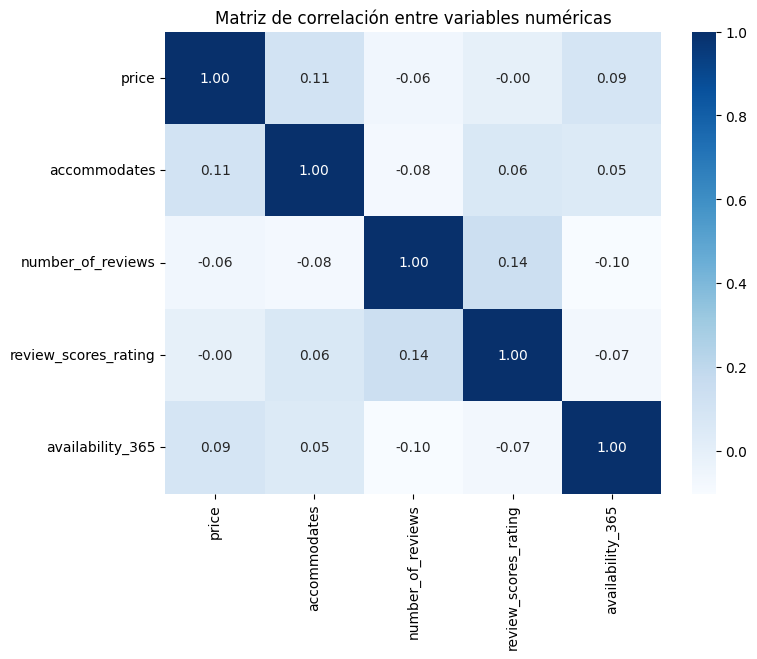

In [78]:
# Generamos un mapa de calor para verlo de forma mas visual
plt.figure(figsize=(8,6))
sns.heatmap(correlaciones, annot=True, cmap="Blues", fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()


La matriz de correlación muestra que no existen relaciones lineales fuertes entre las variables numéricas analizadas. El precio presenta correlaciones muy bajas con la capacidad, el número de reseñas, la puntuación y la disponibilidad, lo que indica que estos factores no explican de forma directa las variaciones de precio. La única relación ligeramente destacable es la correlación positiva entre número de reseñas y rating, aunque sigue siendo débil. También se observa una correlación negativa entre reseñas y disponibilidad, coherente con el hecho de que los alojamientos más reservados acumulan más reseñas y tienen menos días libres. En conjunto, las correlaciones sugieren que el precio y la actividad de los alojamientos dependen de factores no numéricos o no incluidos en este conjunto de variables.


### 1. Distribución del precio por tipo de habitación

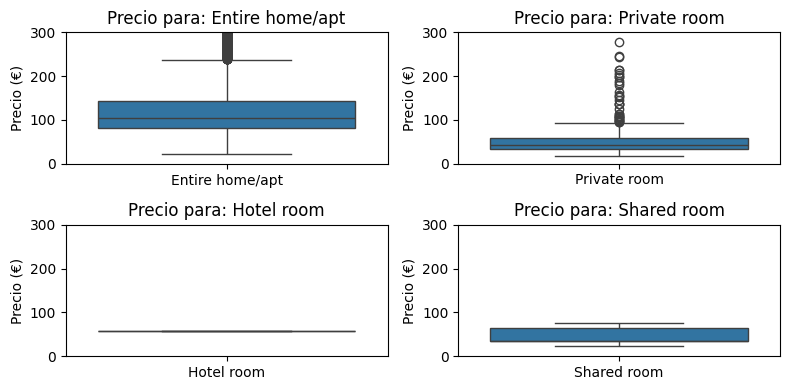

In [71]:
# Distribución del precio por tipo de habitación
 
tipos = df["room_type"].unique()

fig, axes = plt.subplots(2, 2, figsize=(8, 4))
axes = axes.flatten()

for i, tipo in enumerate(tipos):
    sns.boxplot(
        data=df[df["room_type"] == tipo],
        x="room_type",
        y="price",
        ax=axes[i]
    )
    axes[i].set_title(f"Precio para: {tipo}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Precio (€)")
    axes[i].set_ylim(0, 300)  # ajustamos el límite del eje y para ver los valores mas bajos

plt.tight_layout()
plt.show()


Los diagramas de caja muestran diferencias claras entre los tipos de alojamiento. Los apartamentos completos (Entire home/apt) presentan los precios más altos y también la mayor variabilidad, con numerosos valores extremos que indican la presencia de alojamientos significativamente más caros. Las habitaciones privadas (Private room) tienen precios mucho más bajos y una distribución más concentrada, aunque también aparecen algunos outliers. Las habitaciones compartidas (Shared room) son las más económicas y muestran una variabilidad reducida. Por su parte, las habitaciones de hotel (Hotel room) presentan precios intermedios y una distribución relativamente estable.

En conjunto, los resultados confirman que los alojamientos completos son claramente más caros, mientras que las habitaciones privadas y compartidas ofrecen opciones más económicas y homogéneas.

### 2. Relación entre capacidad y precio (mediana)

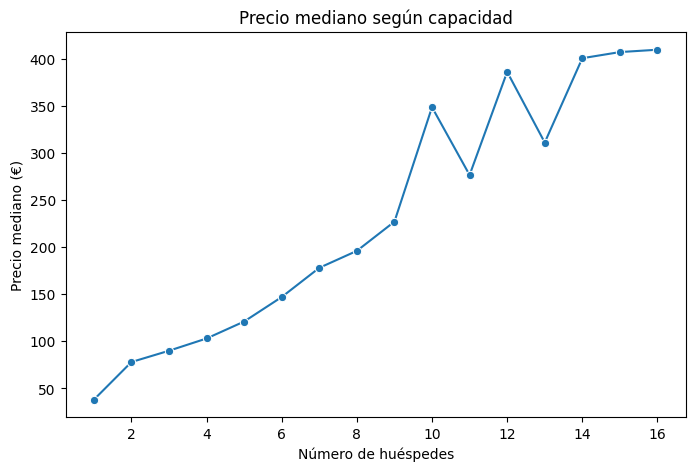

In [94]:
# Relación entre capacidad y precio (mediana)

medianas = df.groupby("accommodates")["price"].median().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(
    data=medianas,
    x="accommodates",
    y="price",
    marker="o"
)
plt.title("Precio mediano según capacidad")
plt.xlabel("Número de huéspedes")
plt.ylabel("Precio mediano (€)")
plt.show()



El gráfico de la mediana del precio según la capacidad muestra una tendencia ascendente clara: a medida que aumenta el número de huéspedes que pueden alojarse en un apartamento , también lo hace el precio mediano. Aunque existen pequeñas fluctuaciones en capacidades altas, la tendencia general confirma que los alojamientos más grandes tienden a ser más caros.

### 3. Análisis multivariante entre la mediana (€) y el tipo de habitación

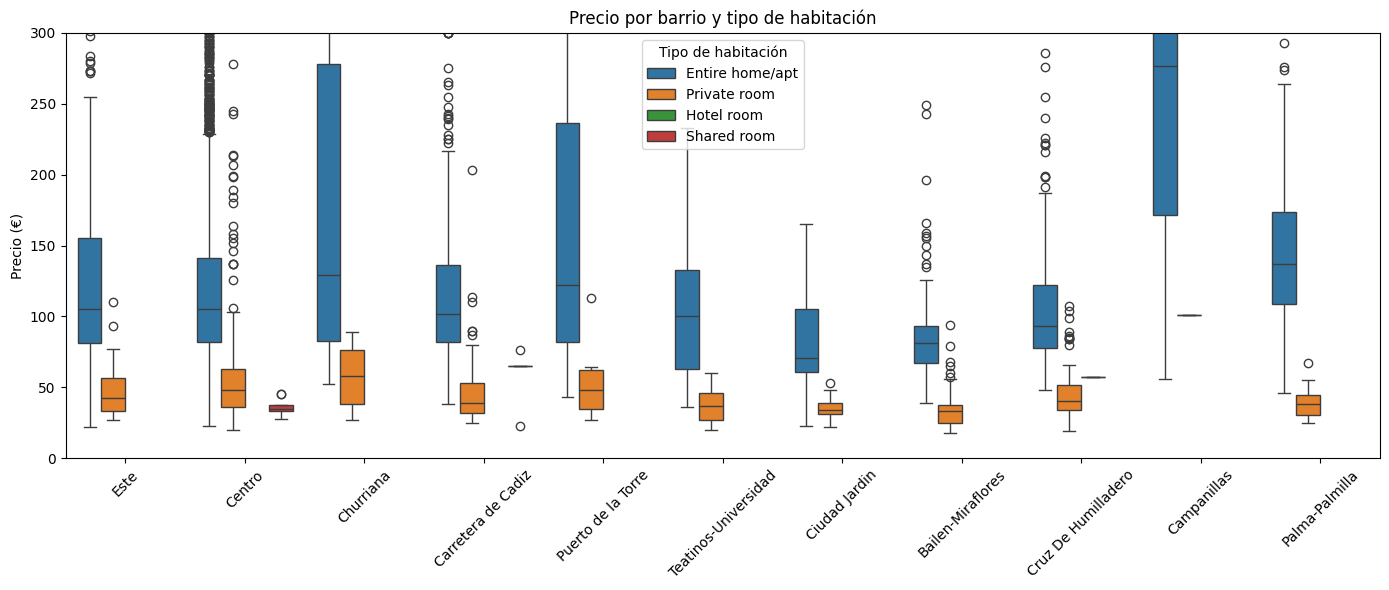

In [107]:
plt.figure(figsize=(14,6))
sns.boxplot(
    data=df,
    x="neighbourhood",
    y="price",
    hue="room_type"
)
plt.xticks(rotation=45)
plt.title("Precio por barrio y tipo de habitación")
plt.ylabel("Precio (€)")
plt.xlabel("")
plt.legend(title="Tipo de habitación")
plt.ylim(0, 300)  # para evitar que los outliers aplasten el gráfico
plt.tight_layout()
plt.show()


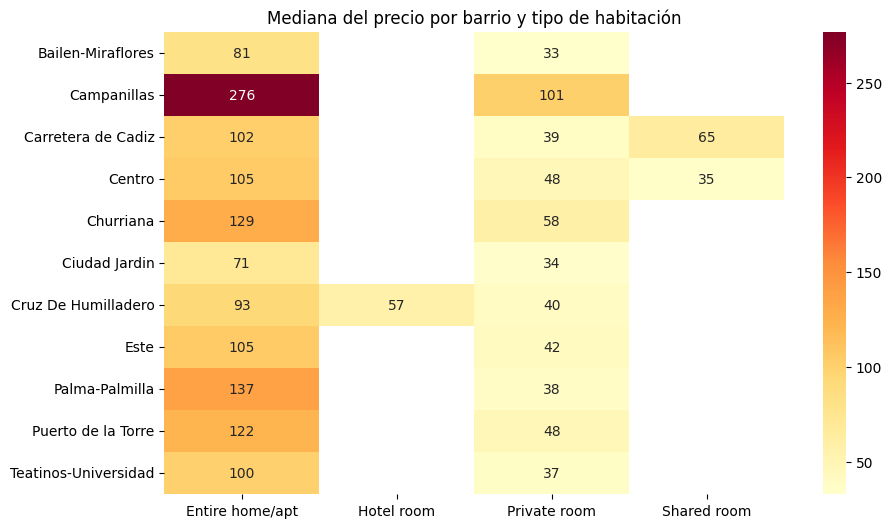

In [104]:
tabla = df.pivot_table(
    values="price",
    index="neighbourhood",
    columns="room_type",
    aggfunc="median"
)

plt.figure(figsize=(10,6))
sns.heatmap(tabla, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Mediana del precio por barrio y tipo de habitación")
plt.xlabel("")
plt.ylabel("")
plt.show()


La comparación entre el boxplot por barrio y tipo de habitación y el heatmap de medianas permite reforzar las conclusiones del análisis multivariante. Mientras que el boxplot muestra la dispersión y variabilidad interna de los precios en cada combinación de barrio y tipo de alojamiento, el heatmap sintetiza esa información destacando las tendencias centrales de forma clara y comparativa. Juntos, ambos gráficos revelan que las viviendas completas son sistemáticamente más caras en todos los barrios, aunque con variaciones notables según la zona, y que las habitaciones privadas y compartidas mantienen precios más homogéneos. Esta combinación de visualizaciones confirma que la localización y el tipo de habitación interactúan de manera decisiva en la determinación del precio, ofreciendo una visión más completa que cualquiera de los gráficos por separado.

### 4. Análisis precio (mediana) y número de reseñas

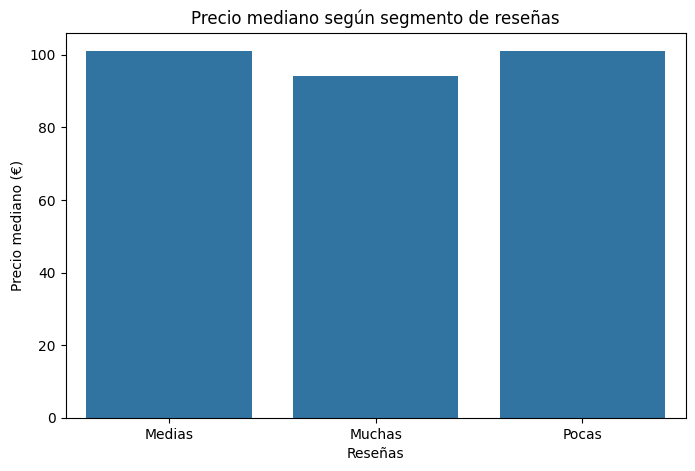

In [112]:
medianas_seg = df.groupby("Segmento Reseñas")["price"].median().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=medianas_seg, x="Segmento Reseñas", y="price")
plt.title("Precio mediano según segmento de reseñas")
plt.xlabel("Reseñas")
plt.ylabel("Precio mediano (€)")
plt.show()


In [111]:
df["number_of_reviews"].corr(df["price"])

np.float64(-0.06061398372488425)

El análisis del precio por segmento de reseñas muestra que no existe una relación clara entre ambas variables. Los alojamientos con muchas reseñas presentan precios medianos ligeramente inferiores, pero las diferencias entre segmentos son pequeñas y no siguen un patrón consistente.

### 5. Análisis precio (mediana) y disponibilidad anual

In [116]:
def clasificar_disponibilidad(x):
    if x <= 90:
        return "Baja"
    elif x <= 180:
        return "Media"
    else:
        return "Alta"

df["Segmento Disponibilidad"] = df["availability_365"].apply(clasificar_disponibilidad)


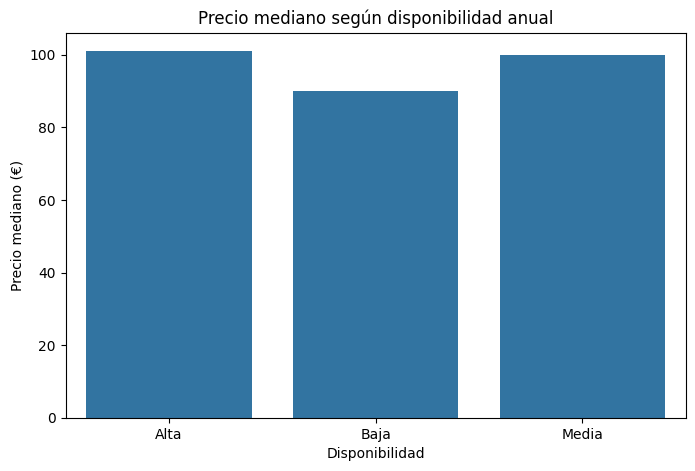

In [118]:
medianas_disp = df.groupby("Segmento Disponibilidad")["price"].median().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=medianas_disp, x="Segmento Disponibilidad", y="price")
plt.title("Precio mediano según disponibilidad anual")
plt.xlabel("Disponibilidad")
plt.ylabel("Precio mediano (€)")
plt.show()


In [119]:
df["availability_365"].corr(df["price"])

np.float64(0.08778137068158547)

La correlación entre disponibilidad anual y precio es de 0.08, un valor extremadamente bajo que indica ausencia de relación lineal entre ambas variables. Esto confirma que la disponibilidad no depende del precio, y que la demanda está influida por otros factores como la ubicación, el tipo de alojamiento o la capacidad del alojamiento.

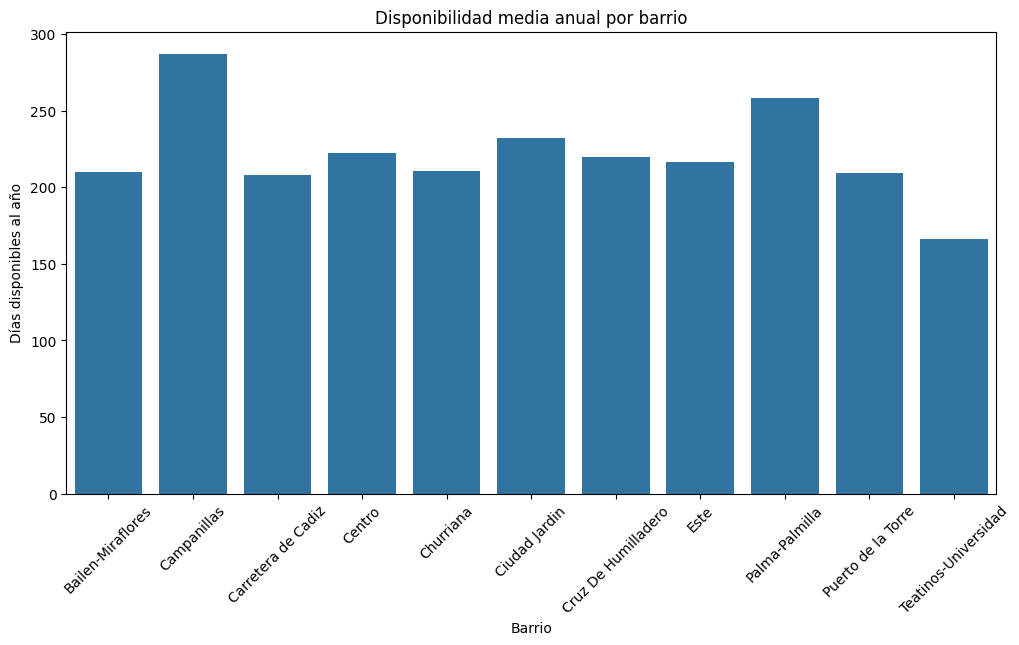

In [120]:
disp_barrio = df.groupby("neighbourhood")["availability_365"].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=disp_barrio, x="neighbourhood", y="availability_365")
plt.xticks(rotation=45)
plt.title("Disponibilidad media anual por barrio")
plt.xlabel("Barrio")
plt.ylabel("Días disponibles al año")
plt.show()

In [122]:
def clasificar_estancia(x):
    if x <= 3:
        return "Corta"
    elif x <= 7:
        return "Media"
    else:
        return "Larga"

df["segmento_estancia"] = df["minimum_nights"].apply(clasificar_estancia)


In [ ]:
moda_estancia_barrio = df.groupby("neighbourhood")["segmento_estancia"].agg(lambda x: x.mode().iloc[0])
moda_estancia_barrio

neighbourhood
Bailen-Miraflores       Corta
Campanillas             Corta
Carretera de Cadiz      Corta
Centro                  Corta
Churriana               Corta
Ciudad Jardin           Corta
Cruz De Humilladero     Corta
Este                    Corta
Palma-Palmilla          Corta
Puerto de la Torre      Corta
Teatinos-Universidad    Corta
Name: segmento_estancia, dtype: str

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13284\1168419089.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=medianas_estancia, x="segmento_estancia", y="price", palette="Blues")


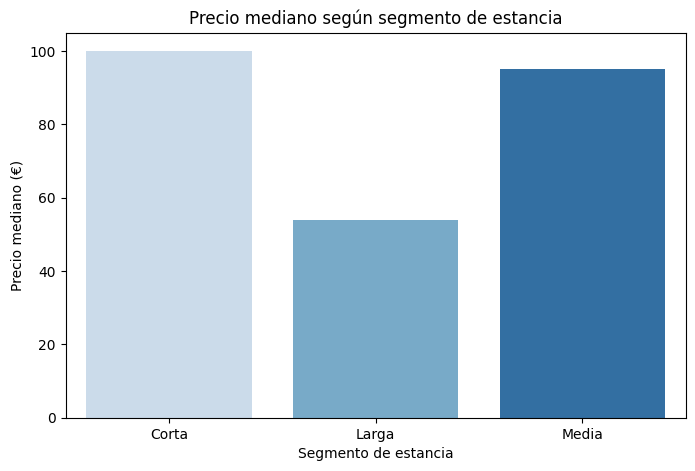

In [128]:
medianas_estancia = df.groupby("segmento_estancia")["price"].median().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=medianas_estancia, x="segmento_estancia", y="price", palette="Blues")
plt.title("Precio mediano según segmento de estancia")
plt.xlabel("Segmento de estancia")
plt.ylabel("Precio mediano (€)")
plt.show()


El análisis del precio mediano por segmento de estancia muestra diferencias claras entre los tipos de alojamiento. Las estancias cortas son las más caras, seguidas muy de cerca por las estancias medias, lo que refleja un mercado orientado al turismo y a la alta rotación. Por el contrario, las estancias largas presentan precios significativamente más bajos, coherentes con un perfil más residencial y con menor demanda turística. Esta distribución confirma que los alojamientos diseñados para estancias breves concentran los precios más elevados del mercado.